In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [6]:
file_path = 'data/F3_sample_data_with_prices_and_brands.csv' 
data = pd.read_csv(file_path)
print(data.columns)

Index(['CODPAIS', 'ANIOCAMPANA', 'CODEBELISTA', 'CODVENTA', 'CODPRODUCTOSAP',
       'ID_OFERTA', 'COD_CATALOGO', 'ID_MACROESTRATEGIA',
       'ID_TIPO_SUBESTRATEGIA', 'DES_TIPO_SUBESTRATEGIA',
       'DES_TIPO_ESTRATEGIA', 'ID_TIPO_GRUPO', 'ID_GRUPO', 'DES_TIPO_GRUPO',
       'ID_SUB_GRUPO', 'NUM_PAGINA', 'PRECIO_OFERTA', 'ES_GRATIS', 'ES_PADRE',
       'ES_GRUPO_PADRE', 'FACTOR_CUADRE', 'FACTOR_REPETICION',
       'COD_TIPO_OFERTA', 'COD_TIPO_PROFIT', 'ID_SUBESTRATEGIA', 'CODCUC',
       'FECHAPROCESO', 'SEXO', 'DESPRODUCTOCUC', 'DESCRIPCIONSAP',
       'DESPRODUCTOGENERICOI', 'DESCATEGORIA', 'DESUNIDADNEGOCIO',
       'DESNEGOCIO', 'DESTIPO', 'DESCLASE', 'DESLINEA', 'DESSUBCATEGORIA',
       'DESSUBCATEGORIASOLO', 'DESSUBTIPO', 'DESESTATUS', 'DESSUBTIPOSOLO',
       'DESMARCA', 'DESTIPOMATERIAL', 'PRECIONORMALMN', 'PRECIONORMALMNPLAN',
       'PRECIOOFERTA', 'PRECIOOFERTAPLAN', 'COMPOSITE_PRIMARY_KEY',
       'FLAGUUFALTANTES', 'TOTAL_DEMAND'],
      dtype='object')


In [9]:
print(data[['CODEBELISTA', "CODPRODUCTOSAP", "FECHAPROCESO", "DESMARCA", "DESCATEGORIA", "DESSUBCATEGORIA", "DESTIPO", "DESSUBTIPO"]])

        CODEBELISTA  CODPRODUCTOSAP FECHAPROCESO DESMARCA  \
0          51638476       200109890   2024-03-21   CYZONE   
1          43958151       200109890   2023-09-28   CYZONE   
2          32132480       200109890   2023-09-11   CYZONE   
3          45948161       200109890   2023-12-19   CYZONE   
4          49904312       200109890   2023-07-11   CYZONE   
...             ...             ...          ...      ...   
292633     40885269       200099686   2023-06-13   CYZONE   
292634     40885269       200115540   2024-06-07   CYZONE   
292635     49793057       200106442   2023-03-22    ESIKA   
292636     50725294       200095170   2023-11-23    ESIKA   
292637     33134193       210095249   2023-10-13   CYZONE   

                        DESPRODUCTOCUC      DESCATEGORIA  \
0       CZ SL MASC MAGNETLASH BLACK 8G        MAQUILLAJE   
1       CZ SL MASC MAGNETLASH BLACK 8G        MAQUILLAJE   
2       CZ SL MASC MAGNETLASH BLACK 8G        MAQUILLAJE   
3       CZ SL MASC MAGNETLA

In [15]:
data['FECHAPROCESO'] = pd.to_datetime(data['FECHAPROCESO'])

# Calculate Recency: Normalize such that 10 is the latest and 1 is the oldest for each consultora
latest_date = data['FECHAPROCESO'].max()
oldest_date = data['FECHAPROCESO'].min()

# For each consultora, calculate Recency and normalize it between 1 and 10 (10 is the latest and 1 is the oldest)
data['Recency'] = data.groupby('CODEBELISTA')['FECHAPROCESO'].transform(
    lambda x: 1 + 9 * ((latest_date - x).dt.days) / ((latest_date - oldest_date).days)
)

# Frequency by CODEBELISTA
frequency = data.groupby('CODEBELISTA').size().reset_index(name='Frequency')

# Normalize Frequency: Scale between 1 and 10
frequency['Frequency'] = 1 + 9 * (frequency['Frequency'] - frequency['Frequency'].min()) / (frequency['Frequency'].max() - frequency['Frequency'].min())

# Aggregate other columns (take the first value per CODEBELISTA or use other aggregation methods)
agg_data = data.groupby('CODEBELISTA').agg(
    CODPRODUCTOSAP = ('CODPRODUCTOSAP', 'first'),
    FECHAPROCESO = ('FECHAPROCESO', 'first'),
    DESMARCA = ('DESMARCA', 'first'),
    DESCATEGORIA = ('DESCATEGORIA', 'first'),
    DESSUBCATEGORIA = ('DESSUBCATEGORIA', 'first'), 
    DESTIPO = ('DESTIPO', 'first'), 
    DESSUBTIPO = ('DESSUBTIPO', 'first'), 
    TOTAL_DEMAND = ("TOTAL_DEMAND", 'first')
).reset_index()

# Merge Frequency and Recency on CODEBELISTA
rf_data = pd.merge(frequency, data[['CODEBELISTA', 'Recency']].drop_duplicates(), on='CODEBELISTA')
rf_data = pd.merge(rf_data, agg_data, on='CODEBELISTA')

# rename category
rf_data['Category'] = rf_data['DESCATEGORIA']

# Extract for Sub category 
rf_data['Sub Category'] = rf_data['DESTIPO'].str.split('/').str[1]

# Extract for Type 
rf_data['Type'] = rf_data['DESTIPO'].str.split('/').str[2]

# Extract for Sub Type 
rf_data['Sub Type'] = rf_data['DESSUBTIPO'].str.split('/').str[3]

# Final DataFrame
print(rf_data.head())

   CODEBELISTA  Frequency   Recency  CODPRODUCTOSAP FECHAPROCESO DESMARCA  \
0      5134323   1.000000  9.673184       200106346   2023-01-07    ESIKA   
1     29478481   3.021683  9.673184       200106346   2023-01-07    ESIKA   
2     29478481   3.021683  1.791899       200106346   2023-01-07    ESIKA   
3     29478481   3.021683  9.346369       200106346   2023-01-07    ESIKA   
4     29478481   3.021683  2.231844       200106346   2023-01-07    ESIKA   

  DESCATEGORIA   DESSUBCATEGORIA                         DESTIPO  \
0   FRAGANCIAS  FRAGANCIAS/DAMAS  FRAGANCIAS/DAMAS/EAU DE PARFUM   
1   FRAGANCIAS  FRAGANCIAS/DAMAS  FRAGANCIAS/DAMAS/EAU DE PARFUM   
2   FRAGANCIAS  FRAGANCIAS/DAMAS  FRAGANCIAS/DAMAS/EAU DE PARFUM   
3   FRAGANCIAS  FRAGANCIAS/DAMAS  FRAGANCIAS/DAMAS/EAU DE PARFUM   
4   FRAGANCIAS  FRAGANCIAS/DAMAS  FRAGANCIAS/DAMAS/EAU DE PARFUM   

                                 DESSUBTIPO  TOTAL_DEMAND    Category  \
0  FRAGANCIAS/DAMAS/EAU DE PARFUM/CON SPRAY            

In [18]:
rf_data.drop(columns= ['DESCATEGORIA', 'DESSUBCATEGORIA', 'DESTIPO', "DESSUBTIPO"], inplace = True)
print(rf_data.head)

<bound method NDFrame.head of       CODEBELISTA  Frequency   Recency  CODPRODUCTOSAP FECHAPROCESO DESMARCA  \
0         5134323   1.000000  9.673184       200106346   2023-01-07    ESIKA   
1        29478481   3.021683  9.673184       200106346   2023-01-07    ESIKA   
2        29478481   3.021683  1.791899       200106346   2023-01-07    ESIKA   
3        29478481   3.021683  9.346369       200106346   2023-01-07    ESIKA   
4        29478481   3.021683  2.231844       200106346   2023-01-07    ESIKA   
...           ...        ...       ...             ...          ...      ...   
1025     51780302   1.361958  4.682961       200105041   2024-03-19    ESIKA   
1026     51780302   1.361958  4.506983       200105041   2024-03-19    ESIKA   
1027     51780302   1.361958  3.601955       200105041   2024-03-19    ESIKA   
1028     51780302   1.361958  3.363128       200105041   2024-03-19    ESIKA   
1029     51780302   1.361958  3.840782       200105041   2024-03-19    ESIKA   

      TOT

In [19]:
rf_data.columns

Index(['CODEBELISTA', 'Frequency', 'Recency', 'CODPRODUCTOSAP', 'FECHAPROCESO',
       'DESMARCA', 'TOTAL_DEMAND', 'Category', 'Sub Category', 'Type',
       'Sub Type'],
      dtype='object')

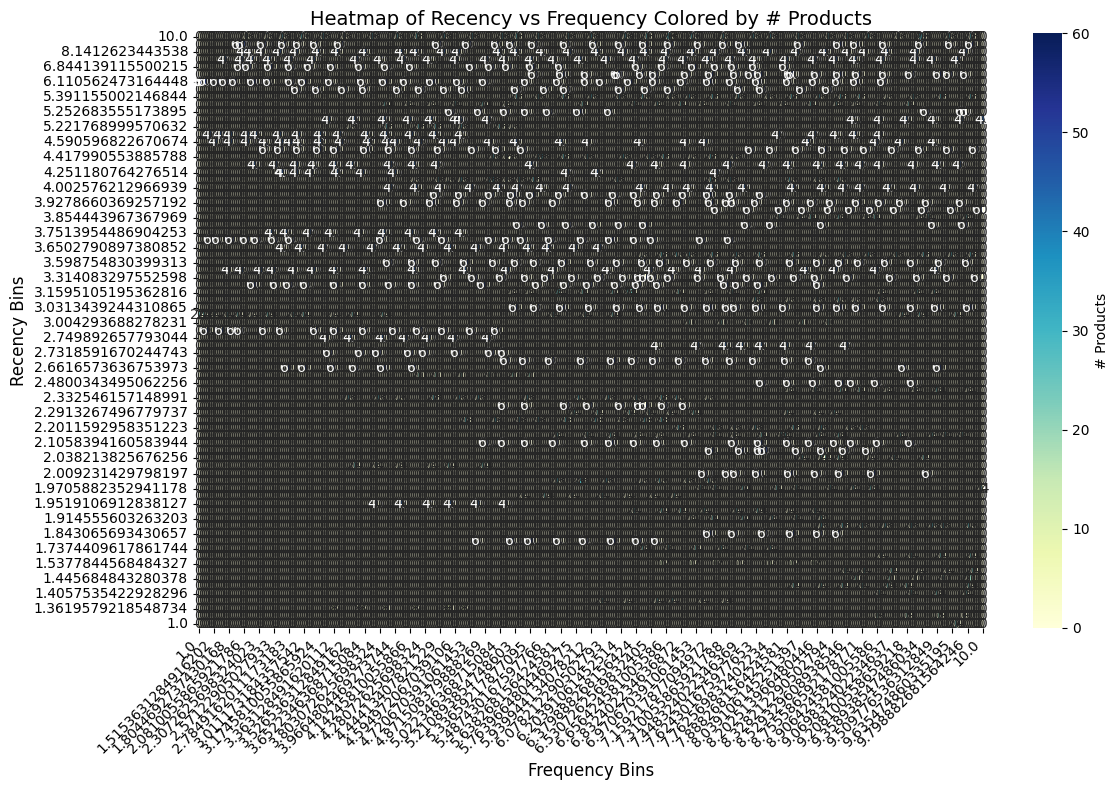

In [20]:
# Pivot the data to create a matrix for heatmap
heatmap_data = rf_data.pivot_table(index='Frequency', columns='Recency', values='TOTAL_DEMAND', aggfunc='sum', fill_value=0)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': '# Products'})
plt.title('Heatmap of Recency vs Frequency Colored by # Products', fontsize=14)
plt.xlabel('Frequency Bins', fontsize=12)
plt.ylabel('Recency Bins', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Invert the y-axis
plt.gca().invert_yaxis()

# Display the plot
plt.show()